<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Data Science and AI
## Lab 7.1.1: Decision Trees

INSTRUCTIONS:

- Read the guides and hints, then create the necessary analysis and code for the scenario below.
- The baseline results (minimum) are:
    - **Accuracy** = 0.6895
    - **ROC AUC**  = 0.5690
- Try to achieve better results!

# Foreword
It is common that companies and professionals start with the data immediately available. Although this approach works, ideally the first step is to identify the problem or question and only then identify and obtain the set of data that can help to solve or answer the problem.

Also, given the current abundance of data, processing power and some particular machine learning methods, there could be a temptation to use ALL the data available. **Quality** is _**better**_ then **Quantity**!

Part of calling this discipline **Data Science** is that it is supposed to follow a process and not reach conclusions without support from evidence.

Moreover, it is a creative, exploratory, labourious and iterative processes. It is part of the process to repeat, review and change when finding a dead-end.

## Scenario:  Predicting whether somebody donated blood in a given month
Blood donations are important in the medical field for a range of reasons, such as assisting patients undergoing surgery, improving the quality of a patient's bloodstream,
managing serious injury/illness or even medical research.

There is a dataset that collects information about how many times a donor donated blood, how much they donated and when they last donated.

Data is courtesy of **Yeh, I-Cheng** via the **UCI Machine Learning** repository:
- Yeh, I-Cheng, Yang, King-Jang, and Ting, Tao-Ming, "Knowledge discovery on RFM model using Bernoulli sequence, "Expert Systems with Applications, 2008, doi:10.1016/j.eswa.2008.07.018.

# Step 1: Define the problem or question
Identify the subject matter and the given or obvious questions that would be relevant in the field.

## Potential Questions
List the given or obvious questions.

* The frequency of how much someone donates?
* Whether or not someone will give blood again?
* The quantity of blood per donation?
* The blood type?

## Actual Question
* Has a person dated blood in March of 2007?

# Step 2: Find the Data
### Blood Transfusion Service Center DataSet
- **Abstract**: Data taken from the **Blood Transfusion Service Center** in Hsin-Chu City in Taiwan.
- Date Donated: 2008-10-03
- Source:
        Original Owner and Donor: Prof. I-Cheng Yeh
        Department of Information Management
        Chung-Hua University,
        Hsin Chu, Taiwan 30067, R.O.C.

- Citation Request:
    **NOTE**: Reuse of this database is unlimited with retention of copyright notice for Prof. I-Cheng Yeh and the following published paper:

        Yeh, I-Cheng, Yang, King-Jang, and Ting, Tao-Ming, "Knowledge discovery on RFM model using Bernoulli sequence, "Expert Systems with Applications, 2008
        
### UCI - Machine Learning Repository
- Center for Machine Learning and Intelligent Systems

The [**UCI Machine Learning Repository**](https://archive.ics.uci.edu/ml/datasets/Blood+Transfusion+Service+Center) is a collection of databases, domain theories, and data generators that are used by the machine learning community for the empirical analysis of machine learning algorithms.

In [1]:
# Import Libraries

import numpy as np
import pandas as pd

# %matplotlib inline
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import seaborn as sns
import warnings

# Step 3: Read the Data
- Read the data (transfusion.data)
- Perform some basic structural cleaning to facilitate the work

In [7]:
df = pd.read_csv('transfusion.data')

In [8]:
df.dtypes

Recency (months)                              int64
Frequency (times)                             int64
Monetary (c.c. blood)                         int64
Time (months)                                 int64
whether he/she donated blood in March 2007    int64
dtype: object

In [9]:
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Recency (months)                            748 non-null    int64
 1   Frequency (times)                           748 non-null    int64
 2   Monetary (c.c. blood)                       748 non-null    int64
 3   Time (months)                               748 non-null    int64
 4   whether he/she donated blood in March 2007  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [10]:
df.describe()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


# Step 4: Explore and Clean the Data
- Perform some initial simple **EDA** (Exploratory Data Analysis)
- Check for
    - **Number of features**
    - **Data types**
    - **Domains, Intervals**
    - **Outliers** (are they valid or spurious data [read or measure errors])
    - **Null** (values not present or coded [as zero of empty strings])
    - **Missing Values** (coded [as zero of empty strings] or values not present)
    - **Coded content** (classes identified by numbers or codes to represent absence of data)

In [12]:
df.isnull().sum()

Recency (months)                              0
Frequency (times)                             0
Monetary (c.c. blood)                         0
Time (months)                                 0
whether he/she donated blood in March 2007    0
dtype: int64

C:\Users\joshp\AppData\Local\Temp\ipykernel_41384\1360782229.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax_hist = sns.distplot(df[c], ax=ax_hist)
C:\Users\joshp\AppData\Local\Temp\ipykernel_41384\1360782229.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax_hist = sns.distplot(df[c], ax=ax_hist)
C:\Users\j

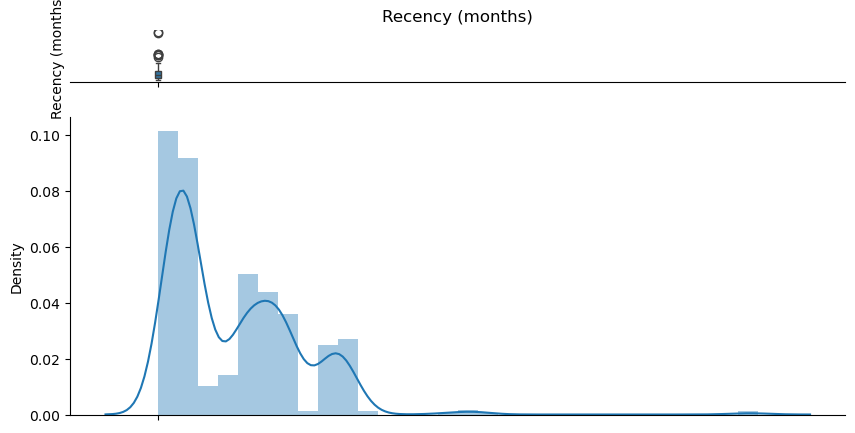

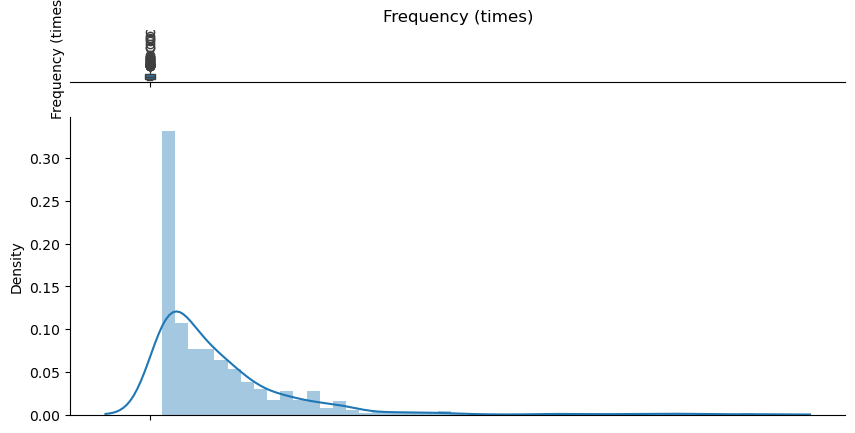

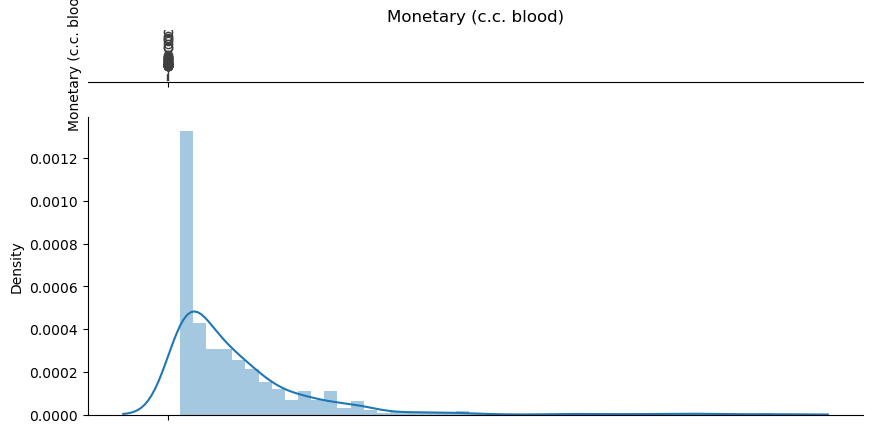

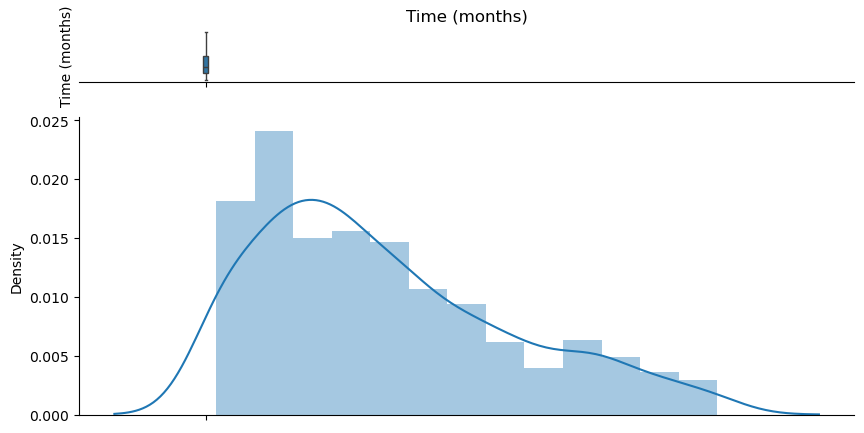

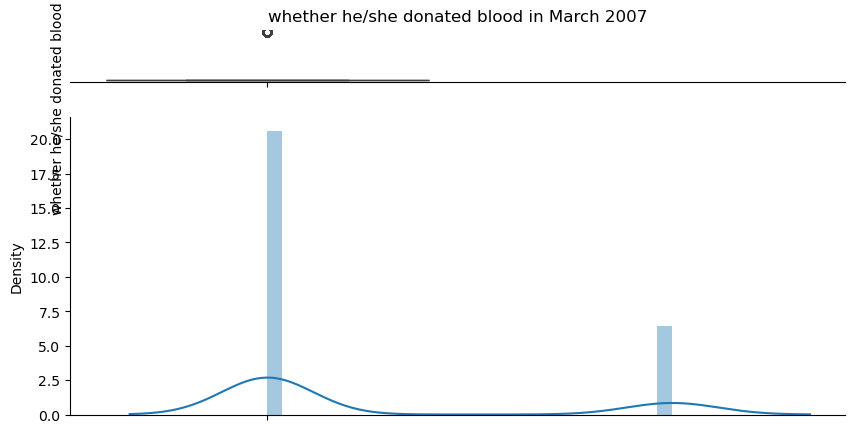

In [13]:
# Check for Outliers
for c in df.columns:
    fig, ax = plt.subplots(2,
                           figsize=(10, 5),
                           sharex=True,
                           gridspec_kw={'height_ratios': (0.15, 0.85)})

    ax_box = ax[0]
    ax_box = sns.boxplot(df[c], ax=ax_box)
    ax_box.set(title=c, yticks=[], xlabel='')
    sns.despine(ax=ax_box, left=True)

    ax_hist = ax[1]
    ax_hist = sns.distplot(df[c], ax=ax_hist)
    ax_hist.set(xlabel='')
    sns.despine(ax=ax_hist)

plt.show()

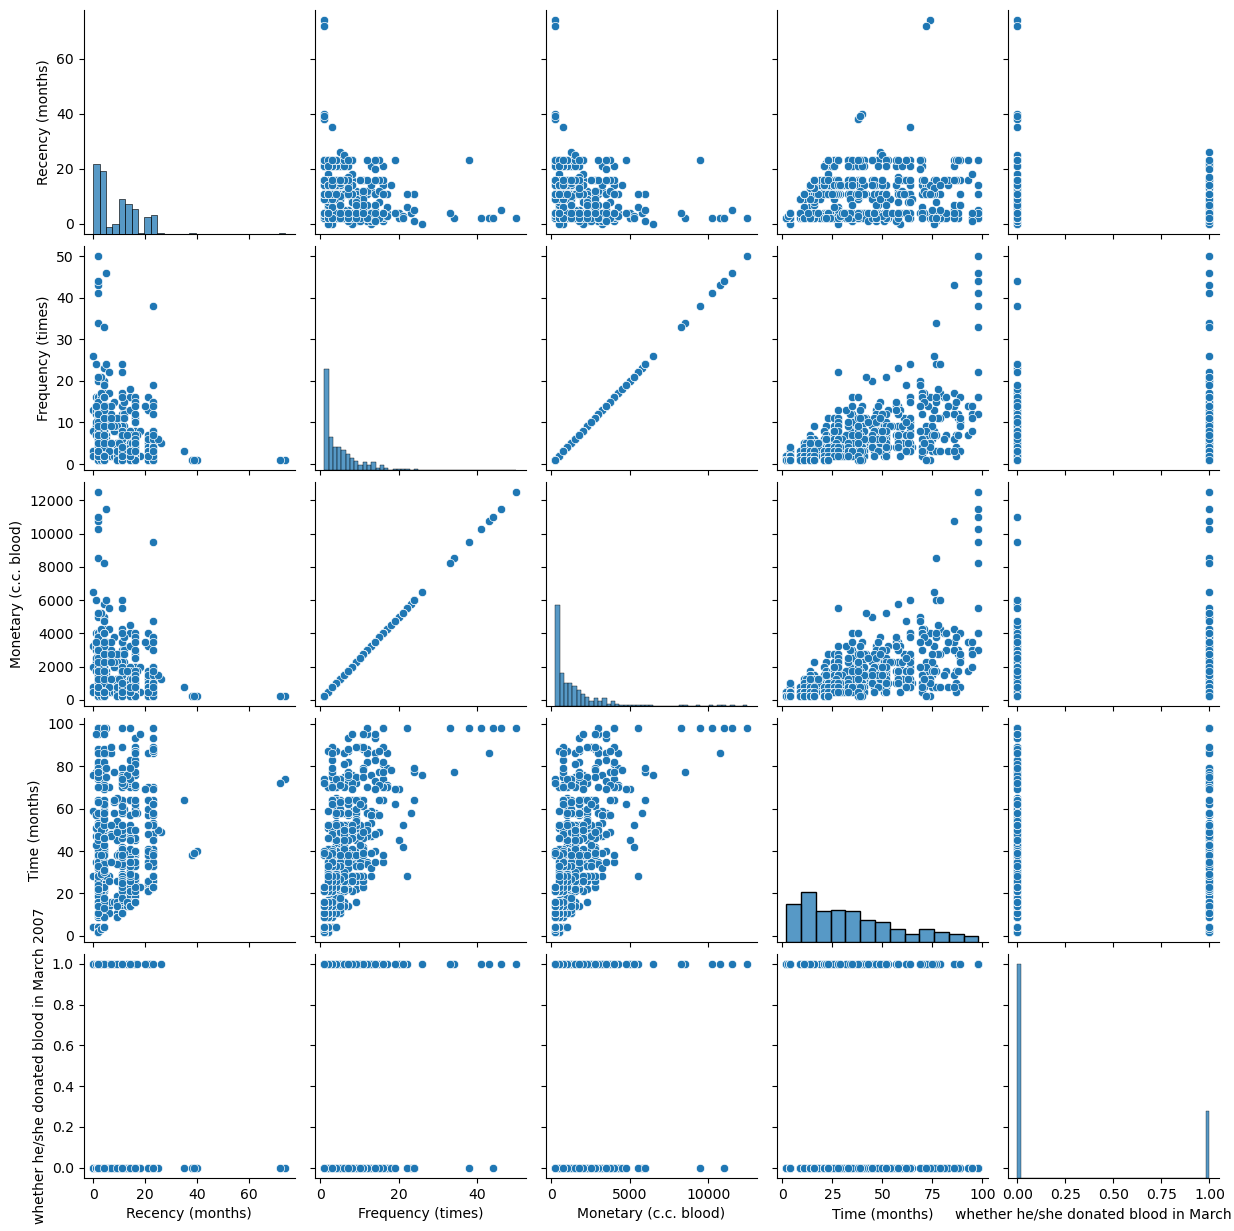

In [14]:
sns.pairplot(df)

# Step 5: Prepare the Data
- Deal with the data as required by the modeling technique
    - **Outliers** (remove or adjust if possible or necessary)
    - **Null** (remove or interpolate if possible or necessary)
    - **Missing Values** (remove or interpolate if possible or necessary)
    - **Coded content** (transform if possible or necessary [str to number or vice-versa])
    - **Feature Engineer** (if useful or necessary)

In [15]:
df['whether he/she donated blood in March 2007'] = df['whether he/she donated blood in March 2007'].astype(bool)

In [16]:
df.dtypes

Recency (months)                              int64
Frequency (times)                             int64
Monetary (c.c. blood)                         int64
Time (months)                                 int64
whether he/she donated blood in March 2007     bool
dtype: object

# Step 6: Modeling
Refer to the Problem and Main Question.
- What are the input variables (features)?
- Is there an output variable (label)?
- If there is an output variable:
    - What is it?
    - What is its type?
- What type of Modeling is it?
    - [X] Supervised
    - [ ] Unsupervised
- What type of Modeling is it?
    - [ ] Regression
    - [ ] Classification (binary)
    - [ ] Classification (multi-class)
    - [ ] Clustering

# Step 7: Split the Data

Need to check for **Supervised** modeling:
- Number of known cases or observations
- Define the split in Training/Test or Training/Validation/Test and their proportions
- Check for unbalanced classes and how to keep or avoid it when splitting

In [1]:
X = df.drop('whether he/she donated blood in March 2007', axis=1)
y = df['whether he/she donated blood in March 2007']
# Create training and testing subsets
test_size = X.shape[0] - 500
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=100666001,
    stratify=y)

SyntaxError: invalid non-printable character U+00A0 (1737753873.py, line 6)

# Step 8: Define a Model

Define the model and its hyper-parameters.

Consider the parameters and hyper-parameters of each model at each (re)run and after checking the efficiency of a model against the training and test datasets.

In [19]:
model = DecisionTreeClassifier()

# Step 9: Fit the Model

In [20]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

# Step 10: Verify and Evaluate the Training Model
- Use the **training** data to make predictions
- What metrics are appropriate for the modeling approach used
- For **Supervised** models:
    - Check the **Training Results** with the **Training Predictions** during development
- Analyze, modify the parameters and hyper-parameters and repeat (within reason) until the model does not improve

Testing visualization...
------------------------------------------------------------
Metric          | Value      | Interpretation
------------------------------------------------------------
Accuracy        | 0.7500     | % of correct total predictions
Precision       | 0.7500     | Ability to avoid False Positives
Recall          | 0.7500     | Ability to find all Positive cases
ROC AUC         | 0.8438     | Overall model ranking quality
------------------------------------------------------------


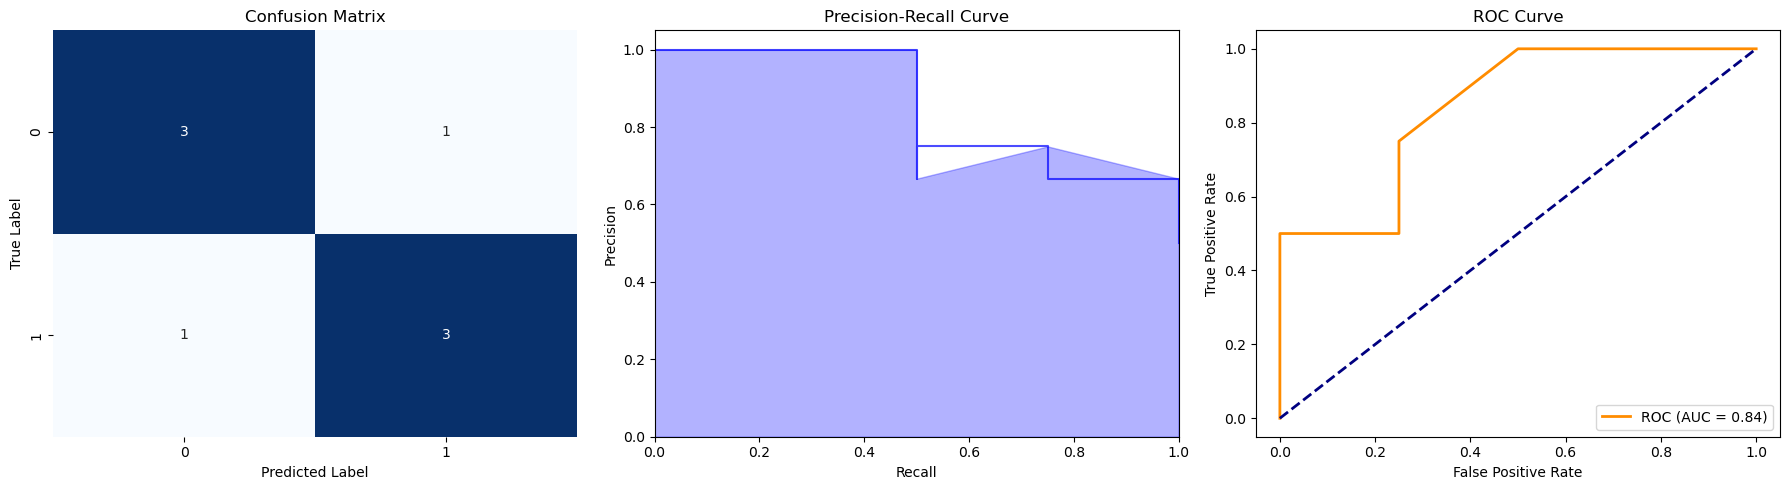

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             roc_auc_score, confusion_matrix, precision_recall_curve, 
                             roc_curve, auc)

# If using a notebook, uncomment the line below:
# %matplotlib inline

def show_summary_report(actual, prediction):
    """
    Standardizes inputs and displays a comprehensive classification report 
    with Confusion Matrix, P-R Curve, and ROC Curve.
    """
    # 1. Data Cleaning: Ensure inputs are numpy arrays
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    else:
        actual = np.array(actual).astype(int)
        
    prediction = np.array(prediction).astype(float)
    
    # 2. Binary conversion for standard metrics (Threshold = 0.5)
    prediction_int = np.round(prediction)

    # 3. Text Report
    print("-" * 60)
    print(f"{'Metric':<15} | {'Value':<10} | {'Interpretation'}")
    print("-" * 60)
    print(f"{'Accuracy':<15} | {accuracy_score(actual, prediction_int):.4f}     | % of correct total predictions")
    print(f"{'Precision':<15} | {precision_score(actual, prediction_int):.4f}     | Ability to avoid False Positives")
    print(f"{'Recall':<15} | {recall_score(actual, prediction_int):.4f}     | Ability to find all Positive cases")
    print(f"{'ROC AUC':<15} | {roc_auc_score(actual, prediction):.4f}     | Overall model ranking quality")
    print("-" * 60)

    # 4. Prepare Plot Data
    mat = confusion_matrix(actual, prediction_int)
    precision_pts, recall_pts, _ = precision_recall_curve(actual, prediction)
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # 5. Plotting
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion Matrix (Standard Orientation)
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')

    # Precision-Recall Curve
    ax[1].step(recall_pts, precision_pts, color='b', alpha=0.7, where='post')
    ax[1].fill_between(recall_pts, precision_pts, alpha=0.3, color='b')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlim([0.0, 1.0])

    # ROC Curve
    ax[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('ROC Curve')
    ax[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# --- SAFETY CHECK: TEST THE FUNCTION ---
# This simulates a model that is 75% accurate.
if __name__ == "__main__":
    test_actual = np.array([0, 0, 0, 0, 1, 1, 1, 1])
    test_probs  = np.array([0.1, 0.2, 0.8, 0.1, 0.9, 0.7, 0.2, 0.9])
    
    print("Testing visualization...")
    show_summary_report(test_actual, test_probs)

In [26]:
y_train_pred = model.predict_proba(X_train)[:,1]

------------------------------------------------------------
Metric          | Value      | Interpretation
------------------------------------------------------------
Accuracy        | 0.9440     | % of correct total predictions
Precision       | 0.9892     | Ability to avoid False Positives
Recall          | 0.7731     | Ability to find all Positive cases
ROC AUC         | 0.9863     | Overall model ranking quality
------------------------------------------------------------


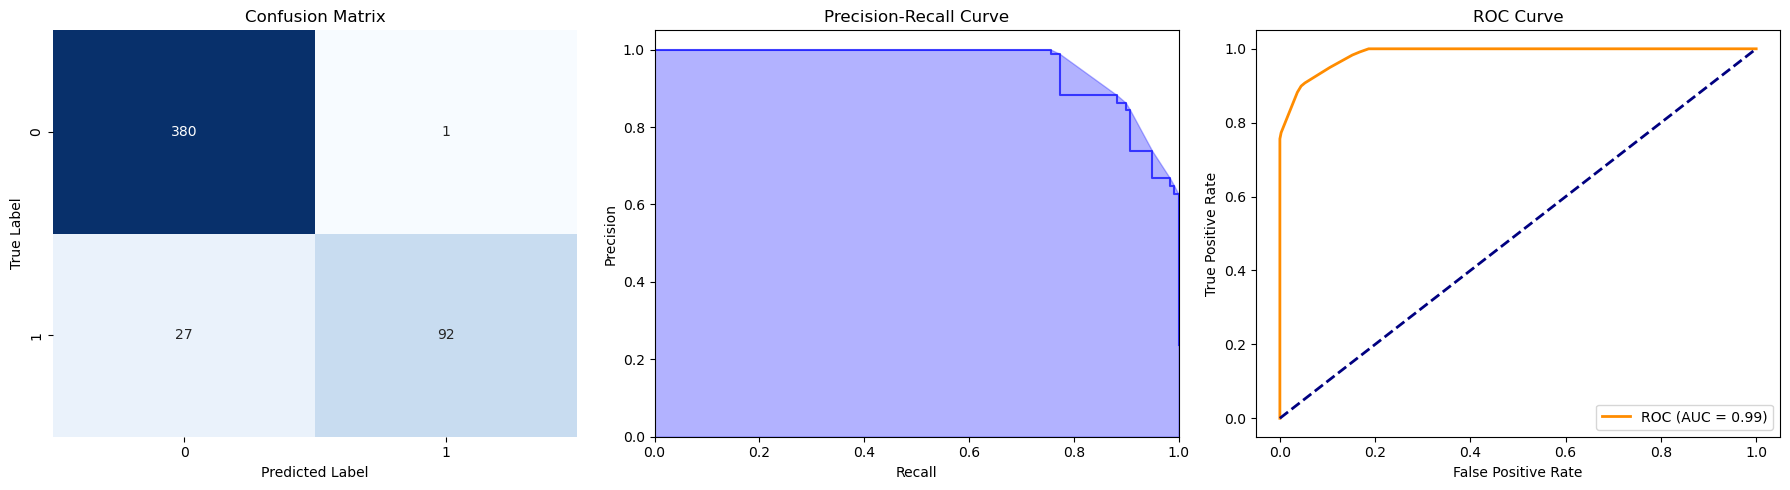

In [29]:
show_summary_report(y_train, y_train_pred)

# Step 11: Make Predictions and Evaluate the Test Model
**NOTE**: **Do this only after not making any more improvements in the model**.

- Use the **test** data to make predictions
- For **Supervised** models:
    - Check the **Test Results** with the **Test Predictions**

In [30]:
# did this in step 10 (above)

# Step 12: Solve the Problem or Answer the Question
The results of an analysis or modeling can be used:
- As part of a product or process, so the model can make predictions when new input data is available
- As part of a report including text and charts to help understand the problem
- As input for further questions



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



